In [32]:
# Simplified Elastic Net Demo

# This notebook demonstrates our project pipeline in a more compact way

# The full project used a larger data pipeline (involving a PostgreSQL database), but this notebook
# utilizes available API's to construct the dataset, train an ENet model and compare to several baselines

# FOMC Minutes omitted due to time constraints for this file

In [33]:
# Imports 

import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

from sklearn.linear_model import LinearRegression, ElasticNetCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

warnings.filterwarnings("ignore")
np.random.seed(42)

START = "2005-01-01"
END = "2024-12-31"

def monthly_log_return(series):
    monthly = series.resample("ME").last()
    return np.log(monthly / monthly.shift(1))

def fred_series(series_id):
    url = f"https://fred.stlouisfed.org/graph/fredgraph.csv?id={series_id}"

    raw = pd.read_csv(url)

    date_col = raw.columns[0]
    value_col = raw.columns[1]

    raw[date_col] = pd.to_datetime(raw[date_col])
    raw[value_col] = pd.to_numeric(raw[value_col], errors="coerce")

    return raw.set_index(date_col)[value_col]



# Market Data

market = yf.download(
    ["SPY", "^VIX", "FXI", "CL=F"],
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)["Close"]

spy = market["SPY"].dropna()
vix = market["^VIX"].dropna()
fxi = market["FXI"].dropna()
oil = market["CL=F"].dropna()

# Target
spy_log_ret_m = monthly_log_return(spy).rename("spy_log_ret_m")

# Features
spy_monthly = spy.resample("ME").last()

mom_3m_log_lag1 = (
    np.log(spy_monthly / spy_monthly.shift(3))
    .shift(1)
    .rename("mom_3m_log_lag1")
)

vix_monthly = vix.resample("ME").last()

vix_m_lag1 = (
    vix_monthly
    .shift(1)
    .rename("vix_m_lag1")
)

log_vix_m_lag1 = (
    np.log(vix_monthly)
    .shift(1)
    .rename("log_vix_m_lag1")
)

fxi_log_ret_m_lag1 = (
    monthly_log_return(fxi)
    .shift(1)
    .rename("fxi_log_ret_m_lag1")
)

oil_log_ret_m_lag1 = (
    monthly_log_return(oil)
    .shift(1)
    .rename("oil_log_ret_m_lag1")
)

# Macroeconomic Data

cpi = fred_series("CPIAUCSL")
unrate = fred_series("UNRATE")
dgs10 = fred_series("DGS10")

cpi_yoy_pct_lag1 = (
    cpi.resample("ME").last()
    .pct_change(12)
    .mul(100)
    .shift(1)
    .rename("cpi_yoy_pct_lag1")
)

unrate_lag1 = (
    unrate.resample("ME").last()
    .shift(1)
    .rename("unrate_lag1")
)

dgs10_lag1 = (
    dgs10.resample("ME").last()
    .shift(1)
    .rename("dgs10_lag1")
)

# Final Dataset

df = pd.concat([
    spy_log_ret_m,
    mom_3m_log_lag1,
    vix_m_lag1,
    log_vix_m_lag1,
    fxi_log_ret_m_lag1,
    oil_log_ret_m_lag1,
    cpi_yoy_pct_lag1,
    unrate_lag1,
    dgs10_lag1
], axis=1)

df = df.dropna().reset_index()
df = df.rename(columns={"index": "month_end"})

target_col = "spy_log_ret_m"

feature_cols = [
    "mom_3m_log_lag1",
    "vix_m_lag1",
    "log_vix_m_lag1",
    "fxi_log_ret_m_lag1",
    "oil_log_ret_m_lag1",
    "cpi_yoy_pct_lag1",
    "unrate_lag1",
    "dgs10_lag1"
]

print("Rows:", len(df))
display(df.head())

Rows: 236


,month_end,spy_log_ret_m,mom_3m_log_lag1,vix_m_lag1,log_vix_m_lag1,fxi_log_ret_m_lag1,oil_log_ret_m_lag1,cpi_yoy_pct_lag1,unrate_lag1,dgs10_lag1
0,2005-05-31,0.031717,-0.016687,15.31,2.728506,0.013101,-0.108172,3.361793,5.2,4.21
1,2005-06-30,0.001513,-0.005658,13.29,2.587012,-0.012368,0.044259,2.869288,5.1,4.00
2,2005-07-31,0.037548,0.014317,12.04,2.488234,0.044213,0.083574,2.541027,5.0,3.94
3,2005-08-31,-0.009419,0.070778,11.57,2.448416,0.078276,0.069559,3.067160,5.0,4.28
4,2005-09-30,0.007994,0.029642,12.60,2.533697,0.000486,0.129437,3.646934,4.9,4.02


In [34]:
WINDOW = 36

results = []
coef_rows = []

def directional_accuracy(y_true, y_pred):
    return np.mean(
        np.sign(np.asarray(y_true))
        ==
        np.sign(np.asarray(y_pred))
    )

for t in range(WINDOW, len(df)):

    train = df.iloc[t-WINDOW:t]
    test = df.iloc[[t]]

    X_train = train[feature_cols]
    y_train = train[target_col]

    X_test = test[feature_cols]
    y_test = float(test[target_col].iloc[0])

    pred_row = {
        "month_end": test["month_end"].iloc[0],
        "actual": y_test
    }

    # Historical Mean

    pred_row["pred_mean"] = float(y_train.mean())

    # Momentum-only LR

    mom_lr = LinearRegression()

    mom_lr.fit(
        train[["mom_3m_log_lag1"]],
        y_train
    )

    pred_row["pred_mom_lr"] = float(
        mom_lr.predict(
            test[["mom_3m_log_lag1"]]
        )[0]
    )

    # Elastic Net

    enet = Pipeline([
        ("scaler", StandardScaler()),
        ("enet", ElasticNetCV(
            l1_ratio=[0.5, 0.7, 0.9],
            alphas=np.logspace(-2, 0.5, 25),
            cv=TimeSeriesSplit(n_splits=3),
            max_iter=50000,
            random_state=42
        ))
    ])

    enet.fit(X_train, y_train)

    pred_row["pred_enet"] = float(
        enet.predict(X_test)[0]
    )

    coef_map = {
        "month_end": test["month_end"].iloc[0]
    }

    for feature, coef in zip(
        feature_cols,
        enet.named_steps["enet"].coef_
    ):
        coef_map[feature] = coef

    coef_rows.append(coef_map)

    # Tree Model

    tree = RandomForestRegressor(
        n_estimators=300,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )

    tree.fit(X_train, y_train)

    pred_row["pred_tree"] = float(
        tree.predict(X_test)[0]
    )

    results.append(pred_row)

rolling_preds = pd.DataFrame(results)
coef_df = pd.DataFrame(coef_rows)

def metric_block(actual, pred):

    return {
        "RMSE": np.sqrt(
            mean_squared_error(actual, pred)
        ),
        "MAE": mean_absolute_error(actual, pred),
        "Directional Accuracy": directional_accuracy(
            actual,
            pred
        )
    }

metrics_df = pd.DataFrame([
    {
        "Model": "Historical Mean",
        **metric_block(
            rolling_preds["actual"],
            rolling_preds["pred_mean"]
        )
    },
    {
        "Model": "Momentum LR",
        **metric_block(
            rolling_preds["actual"],
            rolling_preds["pred_mom_lr"]
        )
    },
    {
        "Model": "Elastic Net",
        **metric_block(
            rolling_preds["actual"],
            rolling_preds["pred_enet"]
        )
    },
    {
        "Model": "Tree Model",
        **metric_block(
            rolling_preds["actual"],
            rolling_preds["pred_tree"]
        )
    }
])

display(metrics_df)

print("Prediction rows:", len(rolling_preds))
print("Coefficient rows:", len(coef_df))

,Model,RMSE,MAE,Directional Accuracy
0,Historical Mean,0.047004,0.035462,0.635
1,Momentum LR,0.047795,0.035822,0.625
2,Elastic Net,0.050787,0.036474,0.670
3,Tree Model,0.051321,0.037579,0.600


Prediction rows: 200
Coefficient rows: 200


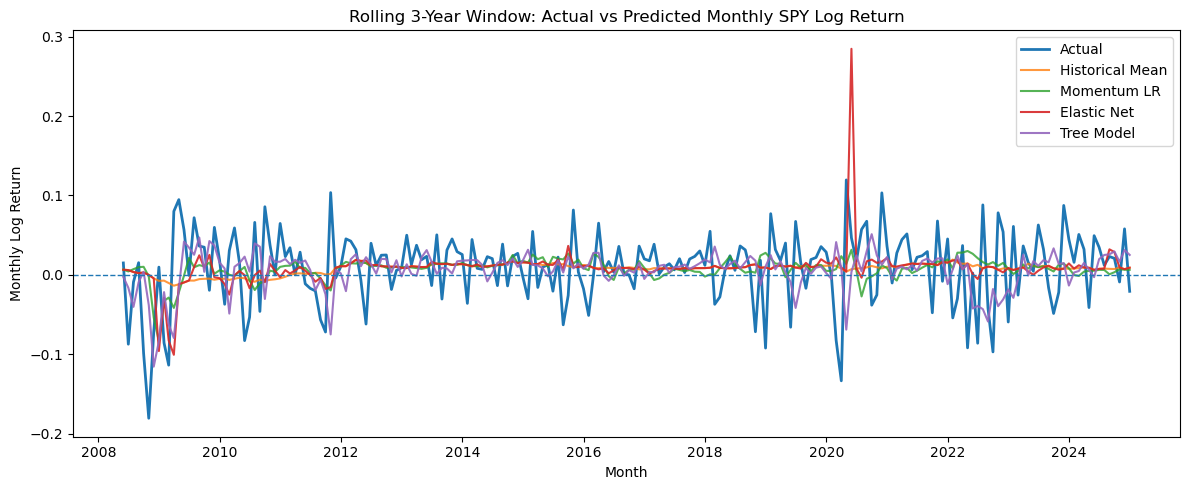

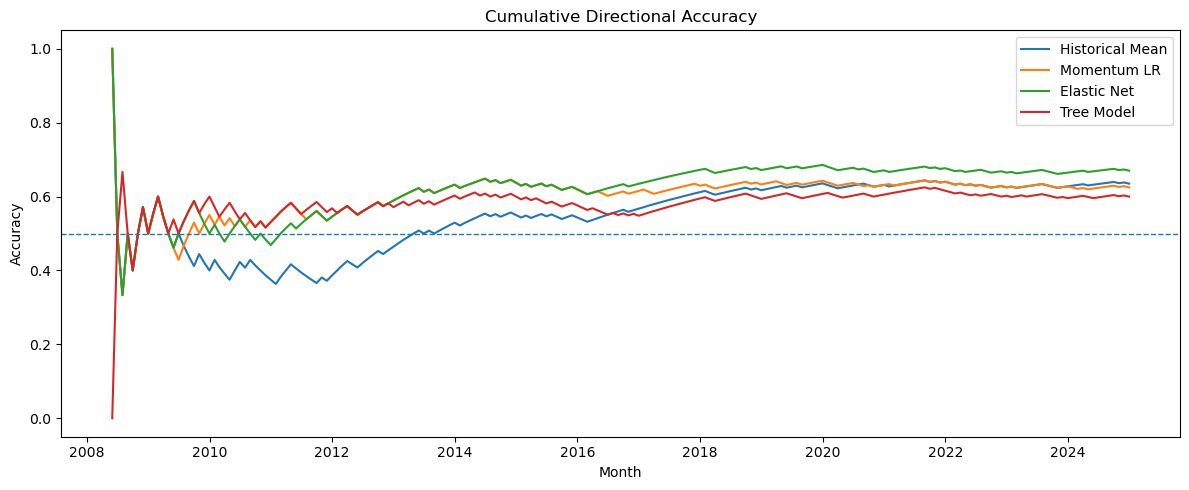

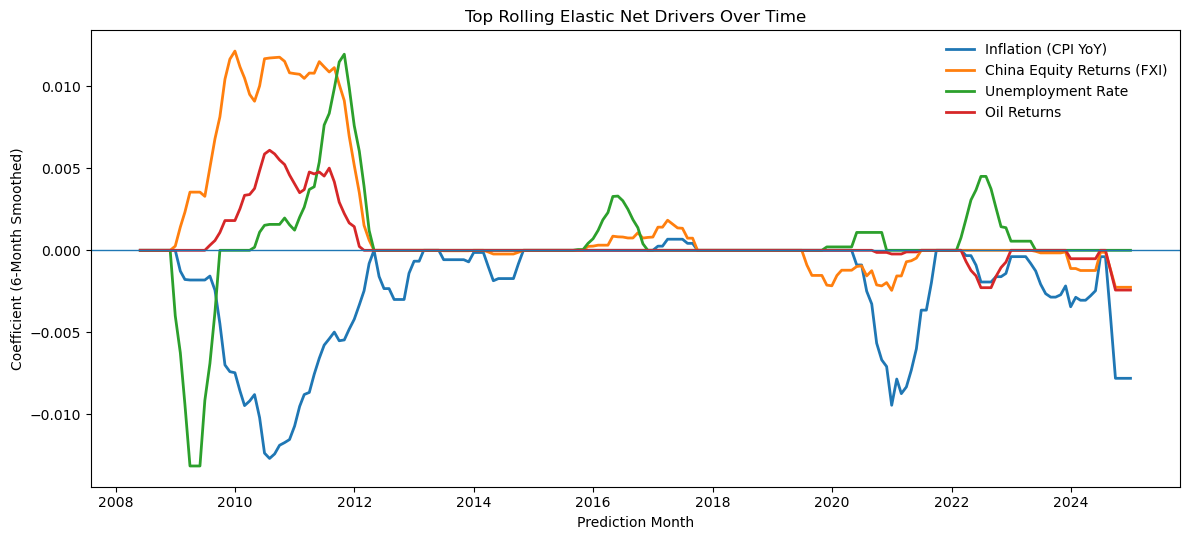

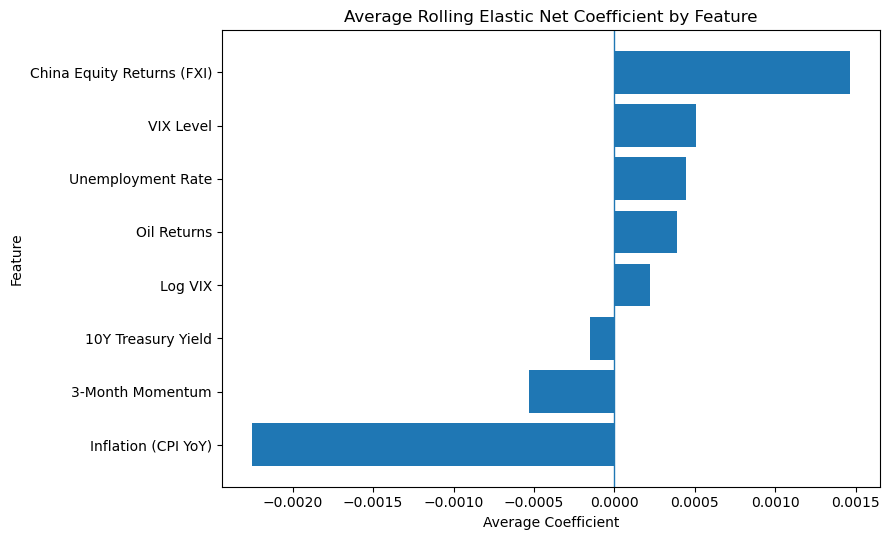

In [35]:
pretty_names = {
    "mom_3m_log_lag1": "3-Month Momentum",
    "vix_m_lag1": "VIX Level",
    "log_vix_m_lag1": "Log VIX",
    "fxi_log_ret_m_lag1": "China Equity Returns (FXI)",
    "oil_log_ret_m_lag1": "Oil Returns",
    "cpi_yoy_pct_lag1": "Inflation (CPI YoY)",
    "unrate_lag1": "Unemployment Rate",
    "dgs10_lag1": "10Y Treasury Yield",
}

def pretty_feature_name(x):
    return pretty_names.get(x, x)

# Plot 1: Actual vs predicted monthly SPY returns

plt.figure(figsize=(12, 5))

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["actual"],
    label="Actual",
    linewidth=2
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_mean"],
    label="Historical Mean",
    alpha=0.8
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_mom_lr"],
    label="Momentum LR",
    alpha=0.8
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_enet"],
    label="Elastic Net",
    alpha=0.9
)

plt.plot(
    rolling_preds["month_end"],
    rolling_preds["pred_tree"],
    label="Tree Model",
    alpha=0.9
)

plt.axhline(0, linewidth=1, linestyle="--")

plt.title("Rolling 3-Year Window: Actual vs Predicted Monthly SPY Log Return")
plt.xlabel("Month")
plt.ylabel("Monthly Log Return")
plt.legend()
plt.tight_layout()
plt.show()


# Plot 2: Cumulative directional accuracy

plot_df = rolling_preds.copy()

plot_df["da_mean"] = (
    np.sign(plot_df["actual"]) == np.sign(plot_df["pred_mean"])
).expanding().mean()

plot_df["da_mom"] = (
    np.sign(plot_df["actual"]) == np.sign(plot_df["pred_mom_lr"])
).expanding().mean()

plot_df["da_enet"] = (
    np.sign(plot_df["actual"]) == np.sign(plot_df["pred_enet"])
).expanding().mean()

plot_df["da_tree"] = (
    np.sign(plot_df["actual"]) == np.sign(plot_df["pred_tree"])
).expanding().mean()

plt.figure(figsize=(12, 5))

plt.plot(plot_df["month_end"], plot_df["da_mean"], label="Historical Mean")
plt.plot(plot_df["month_end"], plot_df["da_mom"], label="Momentum LR")
plt.plot(plot_df["month_end"], plot_df["da_enet"], label="Elastic Net")
plt.plot(plot_df["month_end"], plot_df["da_tree"], label="Tree Model")

plt.axhline(0.50, linestyle="--", linewidth=1)

plt.title("Cumulative Directional Accuracy")
plt.xlabel("Month")
plt.ylabel("Accuracy")
plt.legend()
plt.tight_layout()
plt.show()


# Plot 3: Top Elastic Net drivers over time

coef_plot = coef_df.copy()
coef_plot["month_end"] = pd.to_datetime(coef_plot["month_end"])
coef_plot = coef_plot.sort_values("month_end").set_index("month_end")

coef_features = [
    c for c in feature_cols
    if c in coef_plot.columns
    and coef_plot[c].notna().sum() > 0
    and coef_plot[c].abs().sum() > 0
]

if len(coef_features) > 0:
    coef_smooth = coef_plot[coef_features].rolling(
        window=6,
        min_periods=1
    ).mean()

    top_features = (
        coef_smooth.abs()
        .mean()
        .sort_values(ascending=False)
        .head(4)
        .index
        .tolist()
    )

    plt.figure(figsize=(12, 5.5))

    for feature in top_features:
        plt.plot(
            coef_smooth.index,
            coef_smooth[feature],
            linewidth=2,
            label=pretty_feature_name(feature)
        )

    plt.axhline(0, linewidth=1)
    plt.title("Top Rolling Elastic Net Drivers Over Time")
    plt.xlabel("Prediction Month")
    plt.ylabel("Coefficient (6-Month Smoothed)")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()


    # Plot 4: Average Elastic Net coefficients

    avg_coef = coef_smooth.mean().sort_values()
    labels = [pretty_feature_name(x) for x in avg_coef.index]

    plt.figure(figsize=(9, 5.5))
    plt.barh(labels, avg_coef.values)
    plt.axvline(0, linewidth=1)
    plt.title("Average Rolling Elastic Net Coefficient by Feature")
    plt.xlabel("Average Coefficient")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

else:
    print("No nonzero Elastic Net coefficients available to plot.")